Generate data and save it so later can be analyzed

In [1]:
import MDAnalysis as md
import matplotlib.pyplot as plt
import numpy as np
import cyltransf as ct

file_dir = "data100ns-2008"
output_dir = "output"

u_mean = md.Universe(file_dir + "/md_1.tpr", output_dir + "/md_1_mean.xtc")

`u_mean` already contains the whole information of the mean positions, then one can do manipulation with it more quickly. The only thing is that the routine of centering has to be changed inside. Then we can get the whole fragments list and use it for the next steps.

In [2]:
chains = u_mean.select_atoms("protein").fragments

In [3]:
tot_mol = int((len(chains))/3)
tau = np.zeros(tot_mol)
r2s = np.zeros(tot_mol)
mean_rad = np.zeros(tot_mol)
std_rad = np.zeros(tot_mol)
length = np.zeros(tot_mol)
sep = np.zeros(tot_mol)

for mol in range(tot_mol):
    molecule = chains[3*mol:3*mol + 3]
    molecule_coords = (molecule[0] + molecule[1]+ molecule[2]).positions

    # Length of the Molecule
    length[mol] = (molecule_coords[:,2].max() - molecule_coords[:,2].min()) / 10

    # Apply Filter
    molecule_mean_filt = ct.remove_ends(0.5, molecule_coords) / 10

    # Cylindrical Coordinates
    rad, phi, z = ct.cyl_proj(molecule_mean_filt)
    arc = rad*phi

    # Fit and R2
    tau[mol], b, r2s[mol] = ct.linfitandr2(z, arc)
    
    # "Separation"
    fit = np.polynomial.polynomial.Polynomial((b, tau[mol]))
    sep[mol] = np.std(arc - fit(z))

    # Radius Data
    mean_rad[mol] = np.mean(rad)
    std_rad[mol] = np.std(rad)

/var/folders/mh/rthhjqxd0q17zgrqn8510w6h0000gn/T/ipykernel_4011/1272398224.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tau[mol], b, r2s[mol] = ct.linfitandr2(z, arc)


In [4]:
# For plotting
eval_fit = np.linspace(0, max(mean_rad) + 0.5, 1000)

# Filters
filt_r2 = 0.2
filt_length = 60
filt_sep = 0.6

# Psi - Deg
psi = np.rad2deg(np.atan(abs(tau)))

# Weight test
weights = 1 / std_rad

# Filter data
maskr2 = (r2s >= filt_r2)
tau_filt = tau[maskr2]
psi_filt = psi[maskr2]
mean_rad_filt = mean_rad[maskr2]
std_rad_filt = std_rad[maskr2]
length_filt = length[maskr2]

# Filter for length
masklgth = (length >= filt_length)
psi_lgth = psi[masklgth]
mean_rad_lgth = mean_rad[masklgth]
std_rad_lgth = std_rad[masklgth]
r2s_lgth = r2s[masklgth]
weights_lgth = weights[masklgth]

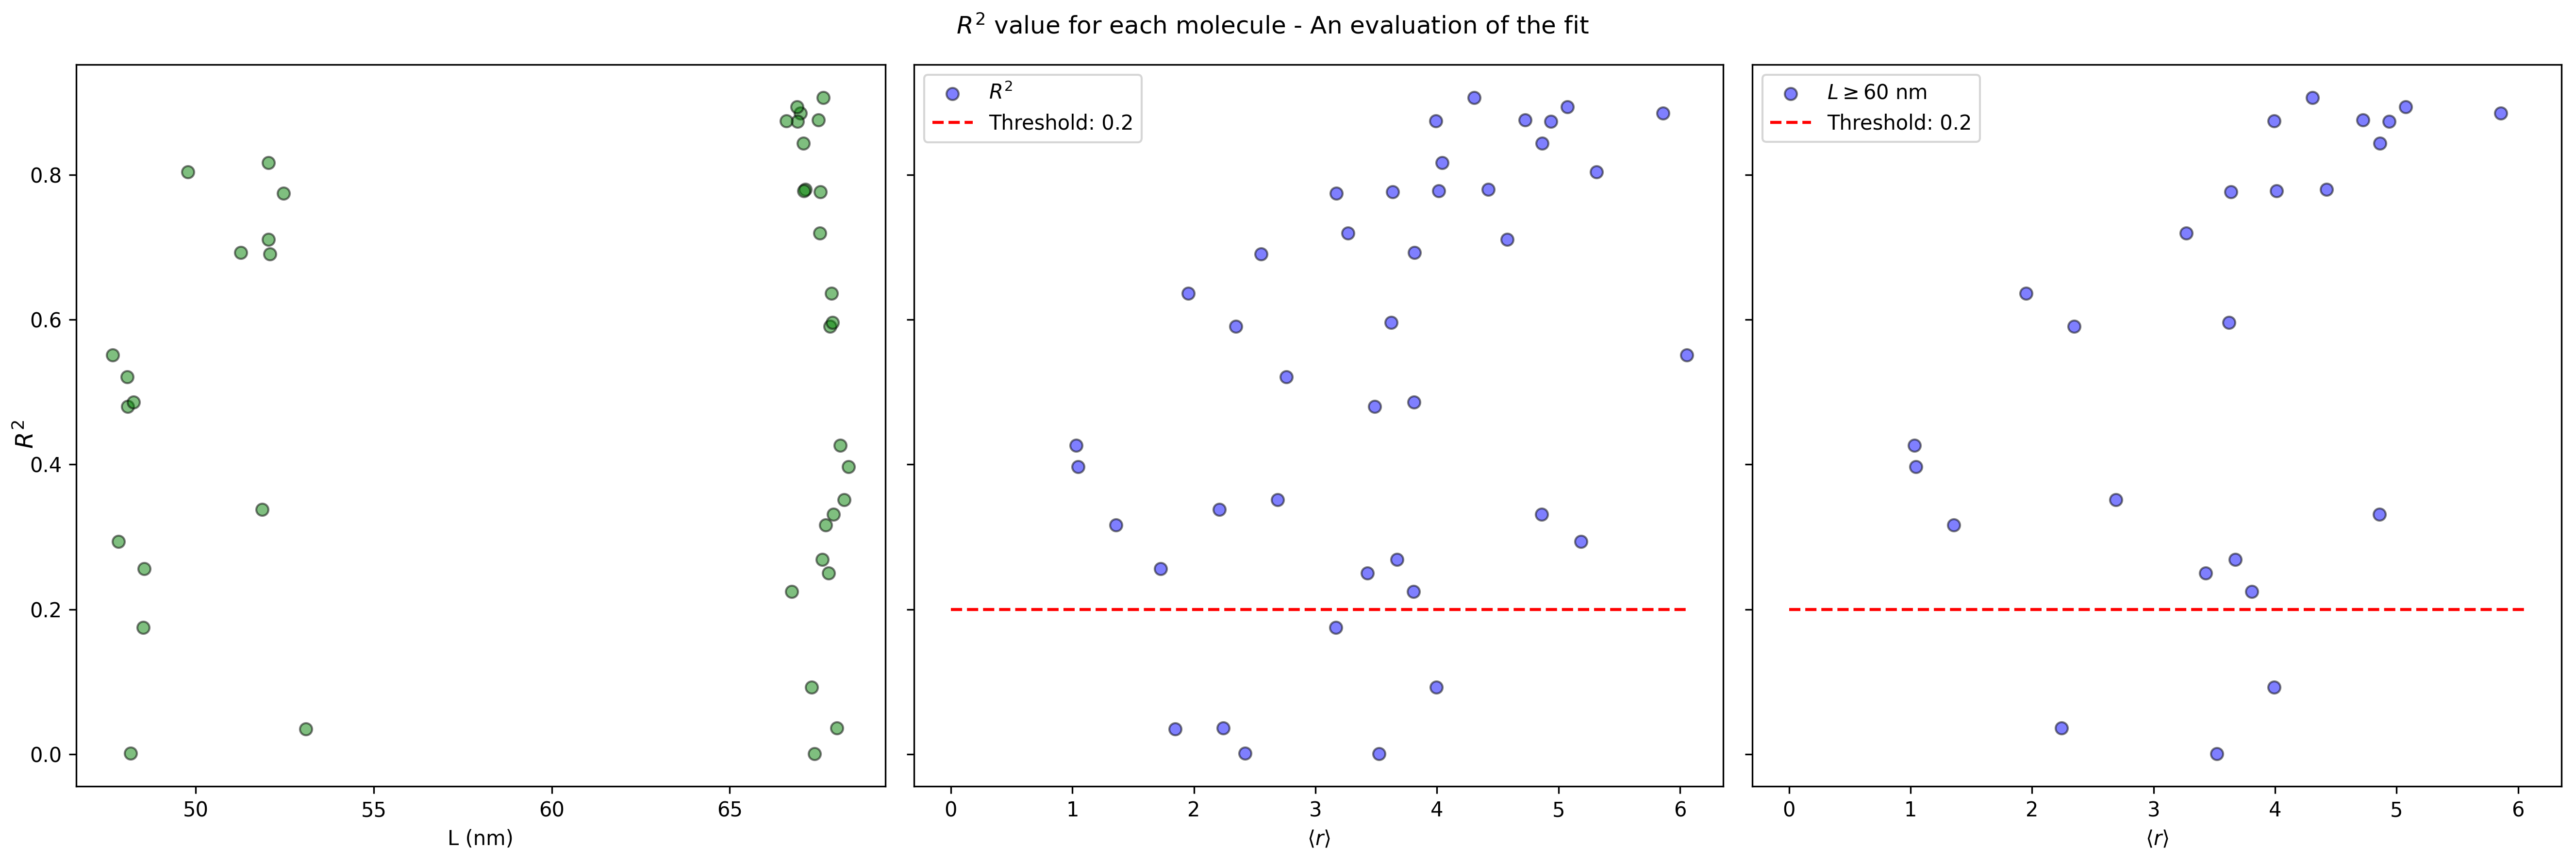

In [5]:
# Visualization of the Rsquared
fig, axs = plt.subplots(1, 3, figsize=(18, 6), dpi=300, sharey=True)
axs[0].scatter(length, r2s, color='g', edgecolor='k', alpha=0.5)
axs[0].set_xlabel(r'L (nm)')

axs[1].scatter(mean_rad, r2s, color='b', edgecolor='k', alpha=0.5, label=r'$R^2$')
axs[1].hlines(filt_r2, 0, max(mean_rad), color='r', linestyle='dashed', label=f'Threshold: {filt_r2}')
axs[1].set_xlabel(r'$\langle r \rangle$')
axs[1].legend()

axs[2].scatter(mean_rad_lgth, r2s_lgth, color='b', edgecolor='k', alpha=0.5, label=rf'$L \geq${filt_length} nm')
axs[2].hlines(filt_r2, 0, max(mean_rad), color='r', linestyle='dashed', label=f'Threshold: {filt_r2}')
axs[2].set_xlabel(r'$\langle r \rangle$')
axs[2].legend()

fig.supylabel(r'$R^2$')
fig.suptitle(r"$R^2$ value for each molecule - An evaluation of the fit")

plt.tight_layout()
plt.show()

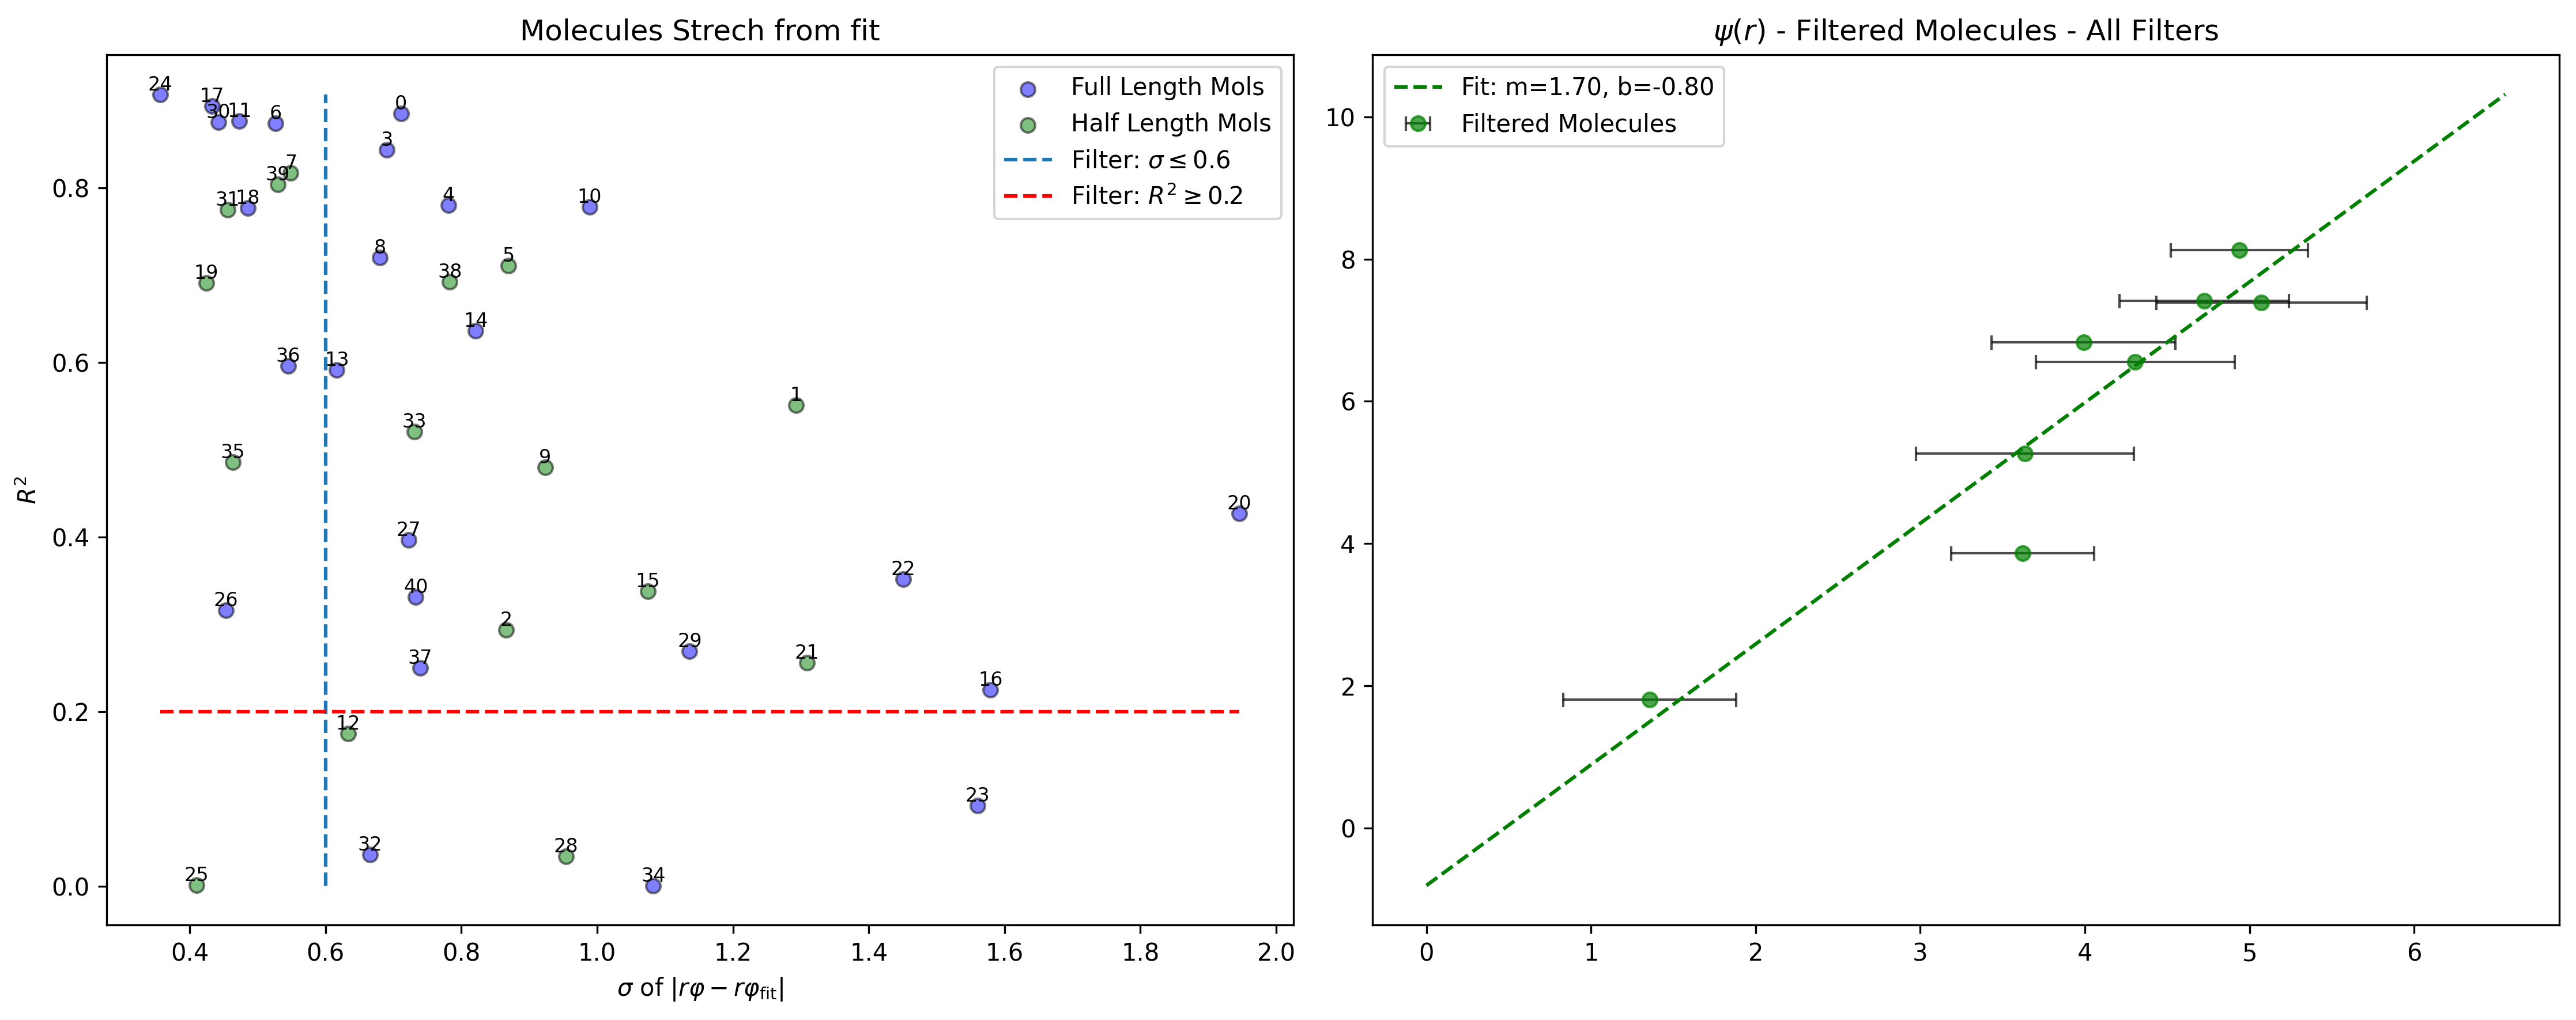

In [6]:
fig, ax = plt.subplots(1,2, figsize=(15,6),dpi=300)

# --- Lenght Distinction Plot ---
r2s_fl, sep_fl = r2s[masklgth], sep[masklgth]
r2s_hl, sep_hl = r2s[~masklgth], sep[~masklgth] # Not Mask
ax[0].scatter(sep_fl, r2s_fl, color='b', edgecolor='k', alpha=0.5, label=r'Full Length Mols')
ax[0].scatter(sep_hl, r2s_hl, color='g', edgecolor='k', alpha=0.5, label=r'Half Length Mols')

# Filters
ax[0].vlines(filt_sep, min(r2s), max(r2s), linestyle='dashed', label=rf"Filter: $\sigma \leq {filt_sep}$")
ax[0].hlines(filt_r2, min(sep), max(sep), color='r', linestyle='dashed', label=rf'Filter: $R^2 \geq {filt_r2}$')

for i, (x, y) in enumerate(zip(sep, r2s)):
    ax[0].text(x, y, str(i), fontsize=8, ha='center', va='bottom')

ax[0].set_title("Molecules Strech from fit")
ax[0].set_ylabel(r'$R^2$')
ax[0].set_xlabel(r'$\sigma$ of $|r\varphi - r\varphi_\text{fit}|$')
ax[0].legend()

# --- Filtered Molecules ---
masksep = (r2s >= filt_r2) & (sep <= filt_sep) & (length >= filt_length)
# masksep = (r2s >= filt_r2) & (sep <= filt_sep)
mean_rad_sep = mean_rad[masksep]
psi_sep = psi[masksep]
std_rad_sep = std_rad[masksep]
weights_sep = weights[masksep]

ax[1].errorbar(mean_rad_sep, psi_sep, xerr=std_rad_sep, fmt='o', color='g', alpha=0.7, ecolor='k', elinewidth=1, capsize=3, label='Filtered Molecules')
b_psif, m_psif = np.polynomial.polynomial.polyfit(mean_rad_sep, psi_sep, 1)
fit = np.polynomial.polynomial.Polynomial((b_psif, m_psif))  
ax[1].plot(eval_fit, fit(eval_fit), linestyle='dashed', color='g', label=f'Fit: m={m_psif:.2f}, b={b_psif:.2f}')
ax[1].set_title(rf"$\psi(r)$ - Filtered Molecules - All Filters")
ax[1].legend()

plt.tight_layout()
plt.show()

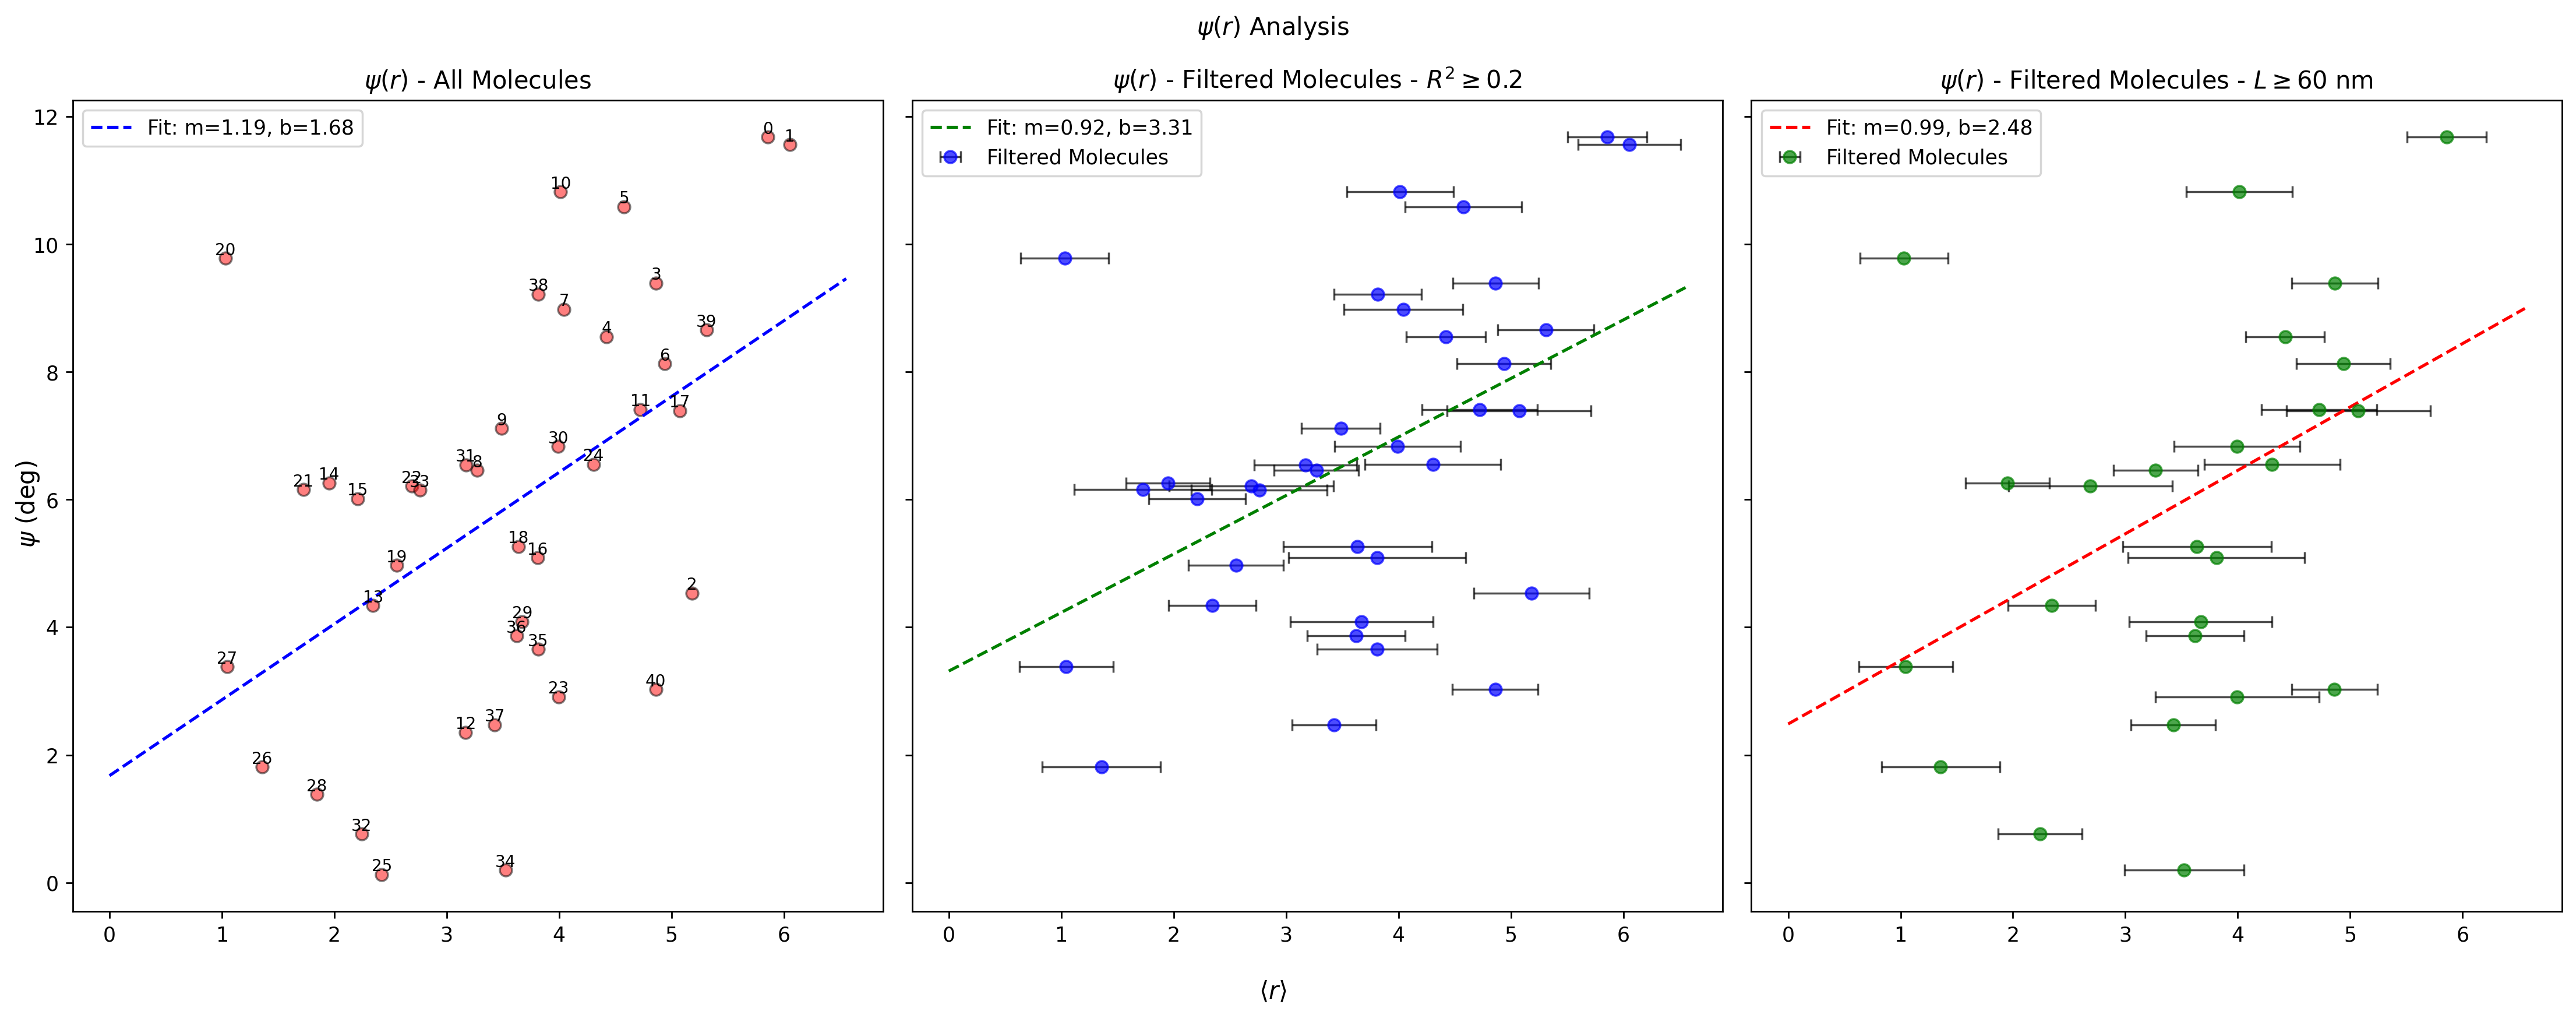

In [7]:
# Plot
fig, ax = plt.subplots(1,3, figsize=(18,7),dpi=250, sharex=1, sharey=1)
# plt.plot(mean_rad, tau, color='k', linestyle='dashed')
ax[0].scatter(mean_rad, psi, color='r', edgecolor='k', alpha=0.5)
b_psi, m_psi = np.polynomial.polynomial.polyfit(mean_rad, psi, 1)
fit = np.polynomial.polynomial.Polynomial((b_psi, m_psi))  
ax[0].plot(eval_fit, fit(eval_fit), linestyle='dashed', color='b', label=f'Fit: m={m_psi:.2f}, b={b_psi:.2f}')

# Label Molecules
for i, (x, y) in enumerate(zip(mean_rad, psi)):
    ax[0].text(x, y, str(i), fontsize=8, ha='center', va='bottom')

ax[0].set_title(r"$\psi(r)$ - All Molecules")
ax[0].legend()

# --- Filtered ---
ax[1].errorbar(mean_rad_filt, psi_filt, xerr=std_rad_filt, fmt='o', color='blue', alpha=0.7, ecolor='k', elinewidth=1, capsize=3, label='Filtered Molecules')
b_psif, m_psif = np.polynomial.polynomial.polyfit(mean_rad_filt, psi_filt, 1)
fit = np.polynomial.polynomial.Polynomial((b_psif, m_psif))  
ax[1].plot(eval_fit, fit(eval_fit), linestyle='dashed', color='g', label=f'Fit: m={m_psif:.2f}, b={b_psif:.2f}')
ax[1].set_title(rf"$\psi(r)$ - Filtered Molecules - $R^2 \geq${filt_r2}")
ax[1].legend()

# --- Filter: Length ---
ax[2].errorbar(mean_rad_lgth, psi_lgth, xerr=std_rad_lgth, fmt='o', color='g', alpha=0.7, ecolor='k', elinewidth=1, capsize=3, label='Filtered Molecules')
b_psif2, m_psif2 = np.polynomial.polynomial.polyfit(mean_rad_lgth, psi_lgth, 1, w=weights_lgth)
fit = np.polynomial.polynomial.Polynomial((b_psif2, m_psif2))  
ax[2].plot(eval_fit, fit(eval_fit), linestyle='dashed', color='r', label=f'Fit: m={m_psif2:.2f}, b={b_psif2:.2f}')
ax[2].set_title(rf"$\psi(r)$ - Filtered Molecules - $L \geq${filt_length} nm")
ax[2].legend()


fig.supxlabel(r'$\langle r \rangle$')
fig.supylabel(r'$\psi$ (deg)')

plt.suptitle(r"$\psi(r)$ Analysis")
plt.tight_layout()
plt.show()

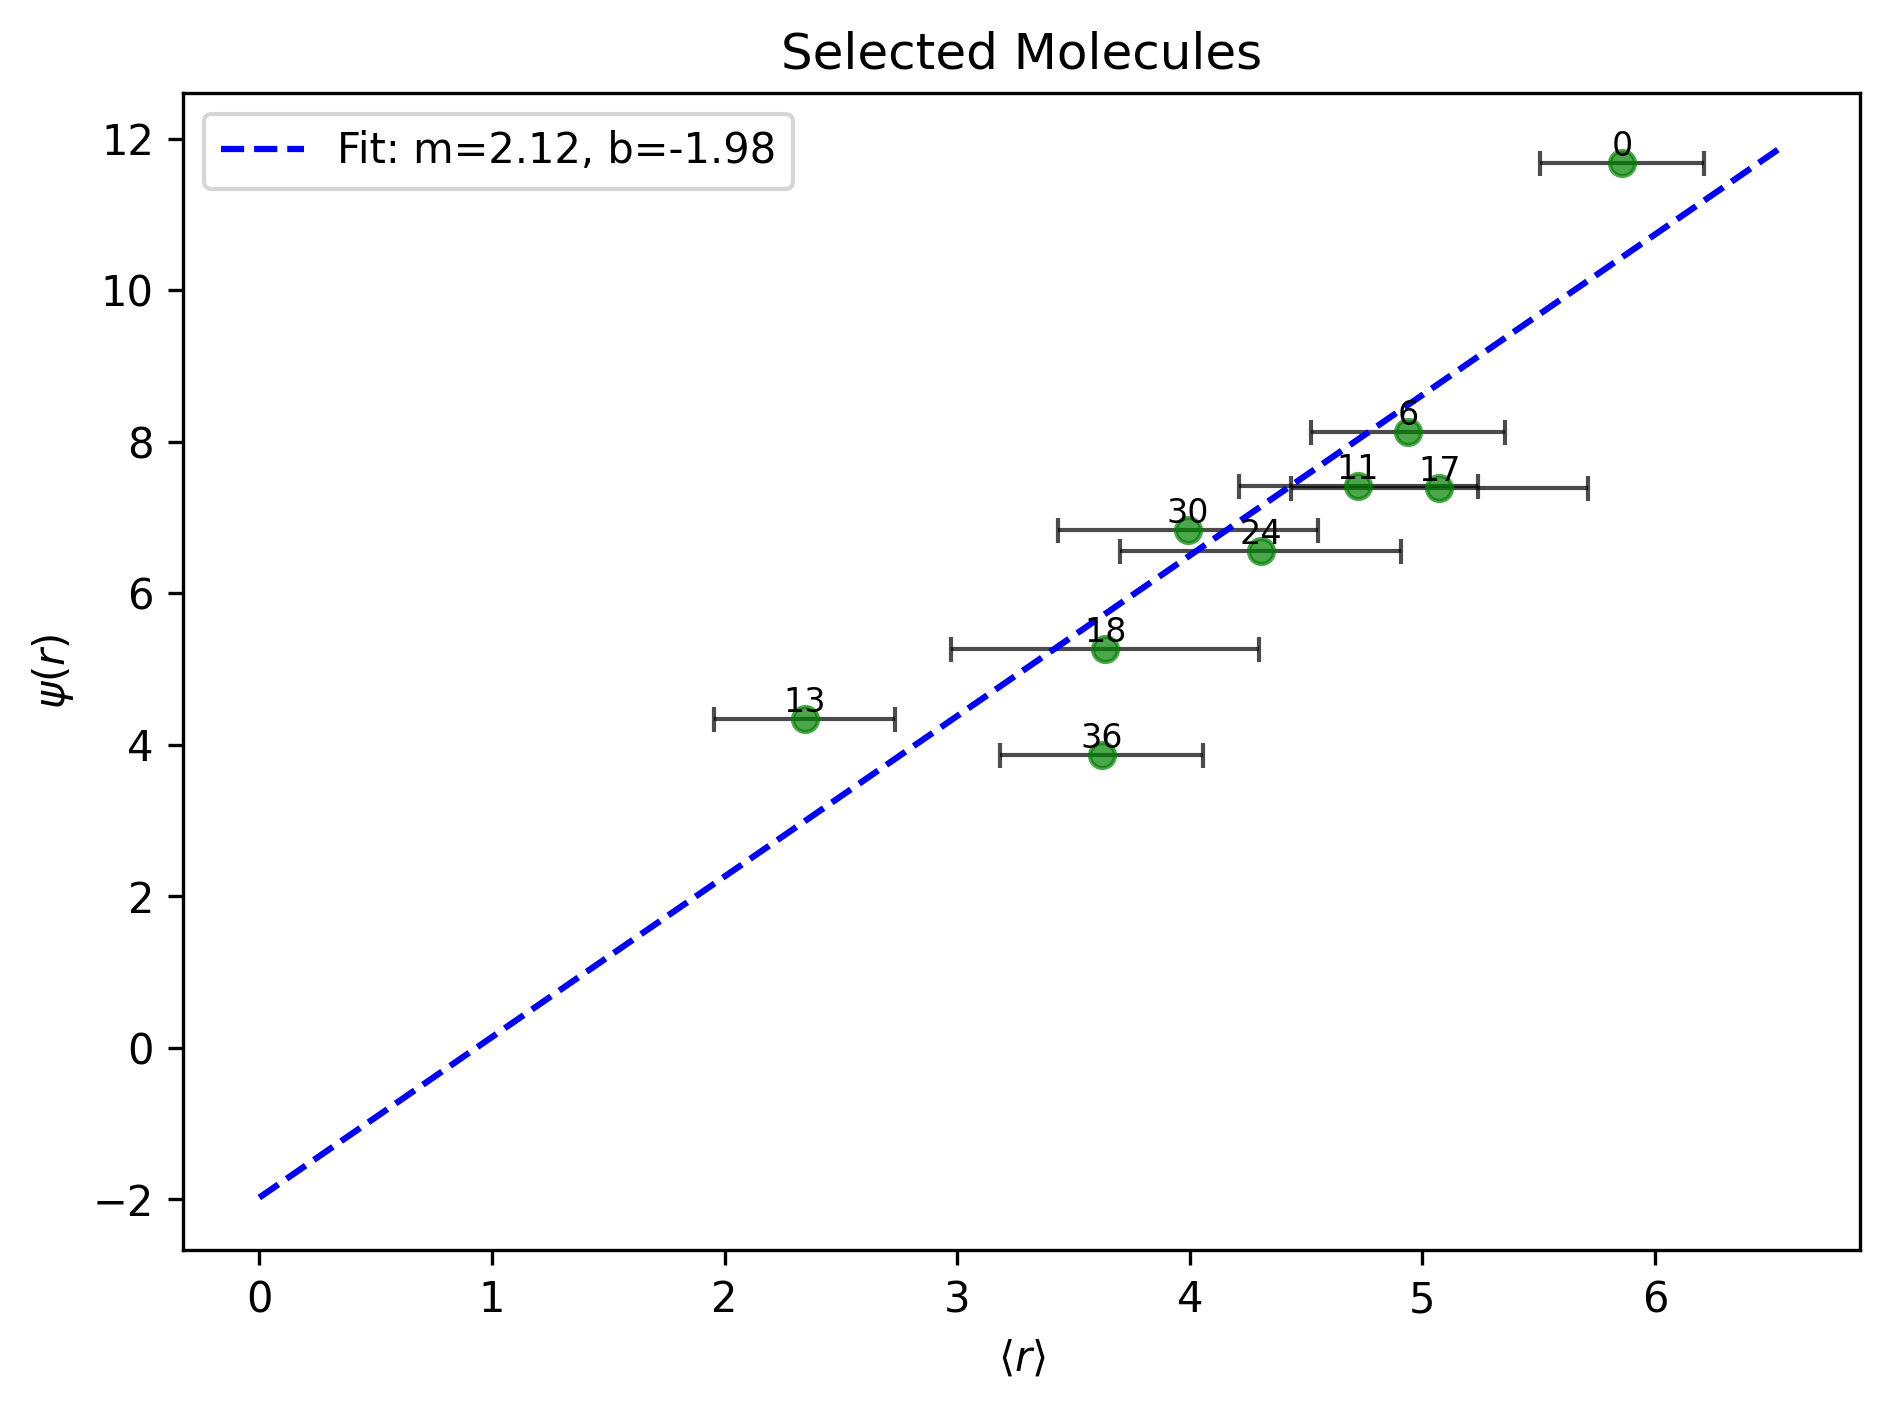

In [8]:
eval_psi = np.linspace(0, max(psi) + 0.5, 1000)

selection = [0, 6, 11, 13, 17, 18, 24, 30, 36]
mr_skt = mean_rad[selection]
psi_skt = psi[selection]
std_skt = std_rad[selection]

w_sktt = 1 / std_skt

plt.figure(dpi=300)

# plt.scatter(mr_skt, psi_skt, color='g', edgecolor='k', alpha=0.5)
plt.errorbar(mr_skt, psi_skt, xerr=std_skt, fmt='o', color='g', alpha=0.7, ecolor='k', elinewidth=1, capsize=3)

# --- New Fit ---
b_psi, m_psi = np.polynomial.polynomial.polyfit(mr_skt, psi_skt, 1, w=w_sktt)
# b_psi, m_psi = np.polynomial.polynomial.polyfit(psi_skt, mr_skt, 1)
fit = np.polynomial.polynomial.Polynomial((b_psi, m_psi))

plt.plot(eval_fit, fit(eval_fit), linestyle='dashed', color='b', label=f'Fit: m={m_psi:.2f}, b={b_psi:.2f}')
# plt.plot(fit(eval_psi), eval_psi, linestyle='dashed', color='b', label=f'Fit: m={m_psi:.2f}, b={b_psi:.2f}')

for i, (x, y) in enumerate(zip(mr_skt, psi_skt)):
    plt.text(x, y, str(selection[i]), fontsize=8, ha='center', va='bottom')

plt.title("Selected Molecules")
plt.ylabel(r'$\psi(r)$')
plt.xlabel(r'$\langle r \rangle$')
plt.legend()
plt.tight_layout()
plt.show()

For Sketching/Testing

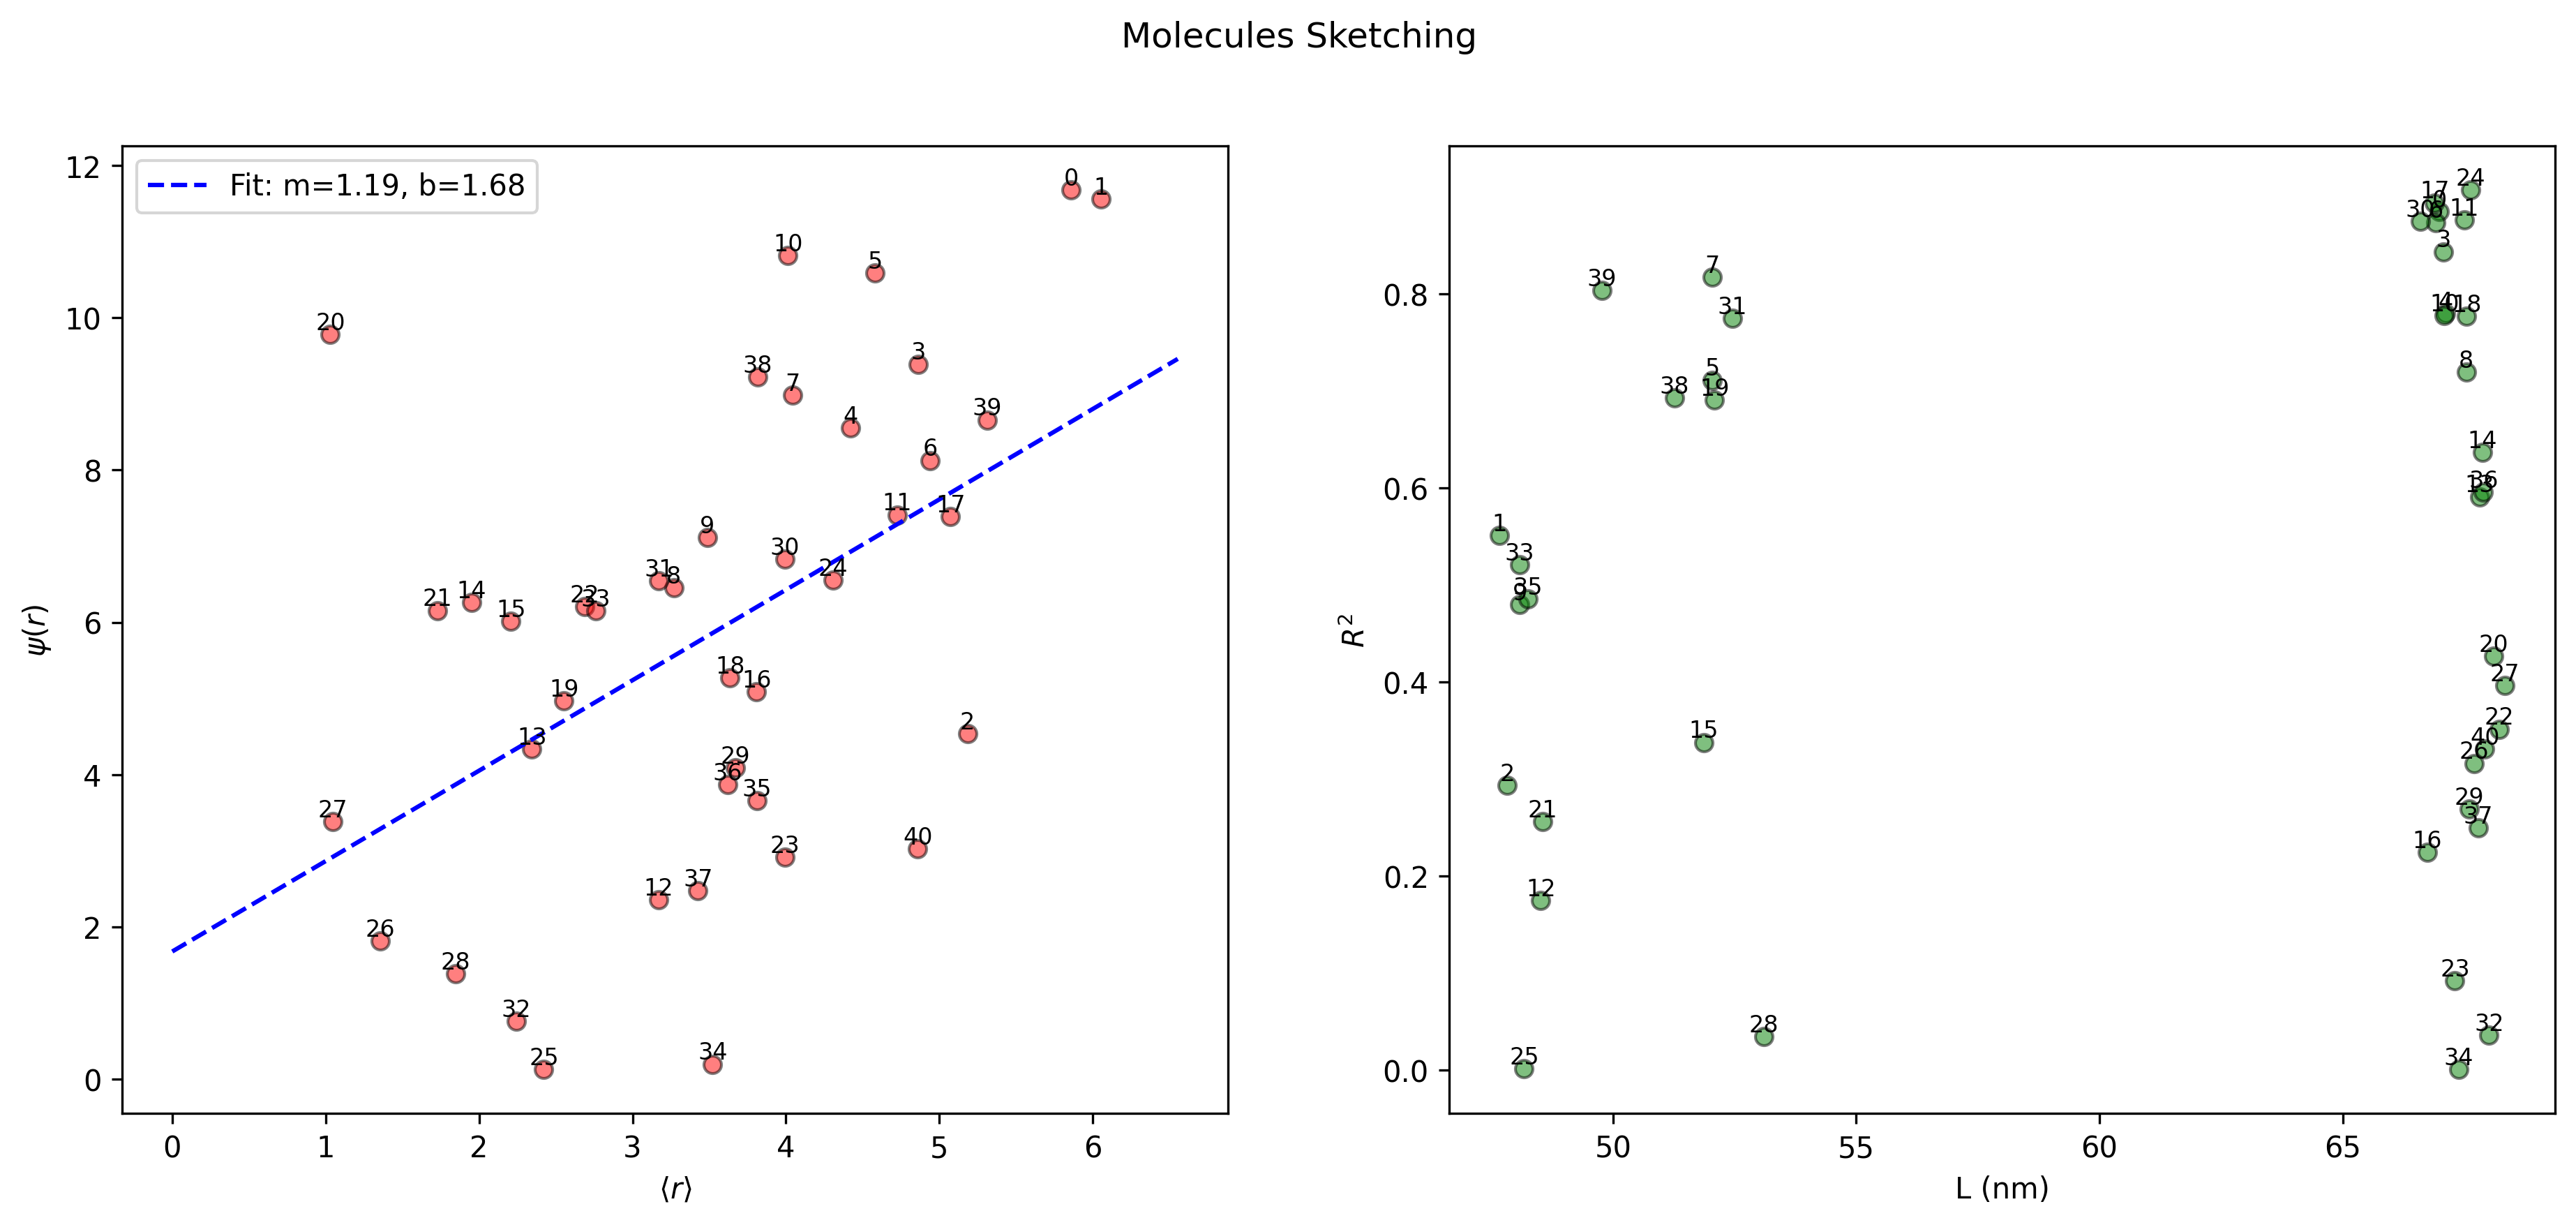

In [9]:
fig, ax = plt.subplots(1,2, figsize=(15,6),dpi=300)

# --- All Molecules Label and Psi Value ---
ax[0].scatter(mean_rad, psi, color='r', edgecolor='k', alpha=0.5)
b_psi, m_psi = np.polynomial.polynomial.polyfit(mean_rad, psi, 1)
fit = np.polynomial.polynomial.Polynomial((b_psi, m_psi))  
ax[0].plot(eval_fit, fit(eval_fit), linestyle='dashed', color='b', label=f'Fit: m={m_psi:.2f}, b={b_psi:.2f}')

for i, (x, y) in enumerate(zip(mean_rad, psi)):
    ax[0].text(x, y, str(i), fontsize=8, ha='center', va='bottom')

ax[0].set_ylabel(r'$\psi(r)$')
ax[0].set_xlabel(r'$\langle r \rangle$')
ax[0].legend()

# --- R^2 Values for Molecule ---
ax[1].scatter(length, r2s, color='g', edgecolor='k', alpha=0.5)

for i, (x, y) in enumerate(zip(length, r2s)):
    ax[1].text(x, y, str(i), fontsize=8, ha='center', va='bottom')

ax[1].set_ylabel(r'$R^2$')
ax[1].set_xlabel(r'L (nm)')

plt.suptitle(r"Molecules Sketching")
plt.show()